In [13]:
import numpy as np

import matplotlib.pyplot as plt


def _is_coord_value(v):
    return isinstance(v, (int, np.integer, str))


def _normalize_coord_value(v):
    if isinstance(v, (int, np.integer)):
        return int(v)
    if isinstance(v, str):
        s = v.strip()
        if not s:
            raise ValueError("Symbolic coordinate labels must be non-empty strings.")
        return s
    raise ValueError("Coordinate values must be integers or strings.")


def _is_coord_pair(x):
    if not (
        isinstance(x, (list, tuple, np.ndarray))
        and len(x) == 2
        and all(_is_coord_value(v) for v in x)
    ):
        return False

    # Reserve ["up"|"right", "up"|"right"] for compressed move tokens.
    if all(isinstance(v, str) and v.strip().lower() in {"up", "right"} for v in x):
        return False

    return True


def _is_move_pair(x):
    return (
        isinstance(x, (list, tuple, np.ndarray))
        and len(x) == 2
        and all(isinstance(v, str) for v in x)
    )


def _changed(a, b):
    return a != b


def _numeric_delta(prev, cur):
    if isinstance(prev, int) and isinstance(cur, int):
        return cur - prev
    return None


def _parse_path_with_compression(path):
    """
    Parse explicit and compressed warping path syntax.

    Supported forms:
      - explicit numeric: [[1,1], [2,1], [3,2], ...]
      - mixed numeric/symbolic:
        [[1,1], [1,2], ["right","right"], [1,"t"], [2,"t+1"], ...]
      - short compressed: [[1,1], ["up","up"], ["i",1]]

    Returns
    -------
    real_i, real_j : np.ndarray(dtype=object)
        Original (possibly symbolic) coordinates.
    plot_i, plot_j : np.ndarray(dtype=int)
        Coordinates used for plotting. Compressed jumps count as one visual step.
    compressed_segments : list[bool]
        Whether each segment is compressed (dotted).
    """
    if isinstance(path, np.ndarray):
        path = path.tolist()

    if not isinstance(path, (list, tuple)) or len(path) == 0:
        raise ValueError("`path` must be a non-empty path description.")
    if not _is_coord_pair(path[0]):
        raise ValueError("Path must start with a coordinate pair [i, j].")

    first_i = _normalize_coord_value(path[0][0])
    first_j = _normalize_coord_value(path[0][1])

    if isinstance(first_i, int) and first_i < 1:
        raise ValueError("Row indices must be >= 1 when numeric.")
    if isinstance(first_j, int) and first_j < 1:
        raise ValueError("Column indices must be >= 1 when numeric.")

    real_i_vals = [first_i]
    real_j_vals = [first_j]
    plot_points = [np.array([1, 1], dtype=int)]
    compressed_segments = []

    t = 1
    while t < len(path):
        token = path[t]

        prev_i = real_i_vals[-1]
        prev_j = real_j_vals[-1]
        prev_plot = plot_points[-1]

        # IMPORTANT: check compressed move tokens before coord pairs.
        if _is_move_pair(token) and all(s.strip().lower() in {"up", "right"} for s in token):
            if t + 1 >= len(path) or not _is_coord_pair(path[t + 1]):
                raise ValueError("Compressed token [move_start, move_end] must be followed by a coordinate [i, j].")

            moves = [s.strip().lower() for s in token]
            allows_up = "up" in moves
            allows_right = "right" in moves

            nxt = path[t + 1]
            cur_i = _normalize_coord_value(nxt[0])
            cur_j = _normalize_coord_value(nxt[1])

            if isinstance(cur_i, int) and cur_i < 1:
                raise ValueError("Row indices must be >= 1 when numeric.")
            if isinstance(cur_j, int) and cur_j < 1:
                raise ValueError("Column indices must be >= 1 when numeric.")

            di_num = _numeric_delta(prev_i, cur_i)
            dj_num = _numeric_delta(prev_j, cur_j)

            if di_num is not None and di_num < 0:
                raise ValueError("Compressed path must be monotone non-decreasing in i.")
            # if dj_num is not None and dj_num < 0:
            #     raise ValueError("Compressed path must be monotone non-decreasing in j.")

            changed_i = _changed(prev_i, cur_i)
            changed_j = _changed(prev_j, cur_j)

            if not allows_up and changed_i:
                raise ValueError("Compressed move descriptor excludes 'up', but i-coordinate changes.")
            if not allows_right and changed_j:
                raise ValueError("Compressed move descriptor excludes 'right', but j-coordinate changes.")

            di_plot = 1 if changed_i else 0
            dj_plot = 1 if changed_j else 0
            end_plot = prev_plot + np.array([di_plot, dj_plot], dtype=int)

            real_i_vals.append(cur_i)
            real_j_vals.append(cur_j)
            plot_points.append(end_plot)
            compressed_segments.append(True)

            t += 2
            continue

        if _is_coord_pair(token):
            cur_i = _normalize_coord_value(token[0])
            cur_j = _normalize_coord_value(token[1])

            if isinstance(cur_i, int) and cur_i < 1:
                raise ValueError("Row indices must be >= 1 when numeric.")
            if isinstance(cur_j, int) and cur_j < 1:
                raise ValueError("Column indices must be >= 1 when numeric.")

            di_num = _numeric_delta(prev_i, cur_i)
            dj_num = _numeric_delta(prev_j, cur_j)

            if di_num is not None and di_num < 0:
                raise ValueError("Warping path must be monotone non-decreasing in i.")
            # if dj_num is not None and dj_num < 0:
            #     raise ValueError("Warping path must be monotone non-decreasing in j.")

            di_plot = di_num if di_num is not None else (1 if _changed(prev_i, cur_i) else 0)
            dj_plot = dj_num if dj_num is not None else (1 if _changed(prev_j, cur_j) else 0)

            end_plot = prev_plot + np.array([di_plot, dj_plot], dtype=int)

            real_i_vals.append(cur_i)
            real_j_vals.append(cur_j)
            plot_points.append(end_plot)
            compressed_segments.append(False)
            t += 1
            continue

        raise ValueError("Invalid token in path. Use [i,j] coordinates and optional [\"up\",\"right\"] tokens.")

    plot_arr = np.asarray(plot_points, dtype=int)

    return (
        np.asarray(real_i_vals, dtype=object),
        np.asarray(real_j_vals, dtype=object),
        plot_arr[:, 0],
        plot_arr[:, 1],
        compressed_segments,
    )


def _labels_from_positions(plot_vals, real_vals):
    positions = np.array(sorted(set(int(v) for v in plot_vals)), dtype=int)
    labels = []
    for p in positions:
        idx = np.where(plot_vals == p)[0][-1]
        labels.append(str(real_vals[idx]))
    return positions, labels


def plot_warping_path(path, k=None, m=None, ax=None, title="Warping Path", save_path=None, legend_fontsize=18):
    """
    Plot a warping path with optional compressed segments.

    Example supported path:
    [[1, 1], [1, 2], ["right", "right"], [1, "t"], [2, "t+1"], ["right", "right"], [2, "k"]]
    """
    real_i, real_j, plot_i, plot_j, compressed_segments = _parse_path_with_compression(path)

    has_compression = any(compressed_segments)

    created_fig = False
    if ax is None:
        created_fig = True
        fig, ax = plt.subplots(figsize=(4.2, 4.2), dpi=300)

    for s in range(len(plot_i) - 1):
        seg_style = ":" if compressed_segments[s] else "-"
        ax.plot(
            [plot_j[s], plot_j[s + 1]],
            [plot_i[s], plot_i[s + 1]],
            color="blue",
            linewidth=1.0,
            linestyle=seg_style,
            zorder=3,
        )

    ax.scatter(plot_j, plot_i, s=14, facecolor="white", edgecolor="black", linewidth=0.8, zorder=4)

    ax.scatter(plot_j[0], plot_i[0], s=20, color="#1f77b4", zorder=5, label="start")
    ax.scatter(plot_j[-1], plot_i[-1], s=20, color="#d62728", zorder=5, label="end")

    if has_compression:
        ax.set_xlim(int(plot_j.min()) - 0.5, int(plot_j.max()) + 0.5)
        ax.set_ylim(int(plot_i.min()) - 0.5, int(plot_i.max()) + 0.5)
        xticks, xlabels = _labels_from_positions(plot_j, real_j)
        yticks, ylabels = _labels_from_positions(plot_i, real_i)
    else:
        # keep legacy numeric-grid behavior when no compression is used
        real_i_num = np.asarray(real_i, dtype=int)
        real_j_num = np.asarray(real_j, dtype=int)
        if k is None:
            k = int(real_i_num.max())
        if m is None:
            m = int(real_j_num.max())
        ax.set_xlim(0.5, m + 0.5)
        ax.set_ylim(0.5, k + 0.5)
        xticks = np.arange(1, m + 1)
        yticks = np.arange(1, k + 1)
        xlabels = [str(x) for x in xticks]
        ylabels = [str(y) for y in yticks]

    ax.set_xticks(xticks)
    ax.set_yticks(yticks)
    ax.set_xticklabels(xlabels)
    ax.set_yticklabels(ylabels)
    ax.tick_params(axis="both", which="major", labelsize=8)

    ax.grid(True, which="major", linestyle="-", linewidth=0.5, alpha=0.35)
    ax.set_aspect("equal", adjustable="box")

    ax.set_xlabel("j", fontsize=8)
    ax.set_ylabel("i", fontsize=8)
    ax.set_title(title, fontsize=10)
    ax.legend(frameon=False, loc="best", fontsize=legend_fontsize)

    for spine in ax.spines.values():
        spine.set_linewidth(0.8)

    if created_fig:
        fig.tight_layout()
        if save_path is not None:
            fig.savefig(save_path, bbox_inches="tight")
    elif save_path is not None:
        ax.figure.savefig(save_path, bbox_inches="tight")

    return ax


# Example:
# path = [[1, 1], [1, 2], ["right", "right"], [1, "t"], [2, "t+1"], ["right", "right"], [2, "k"]]
# plot_warping_path(path)
# plt.show()

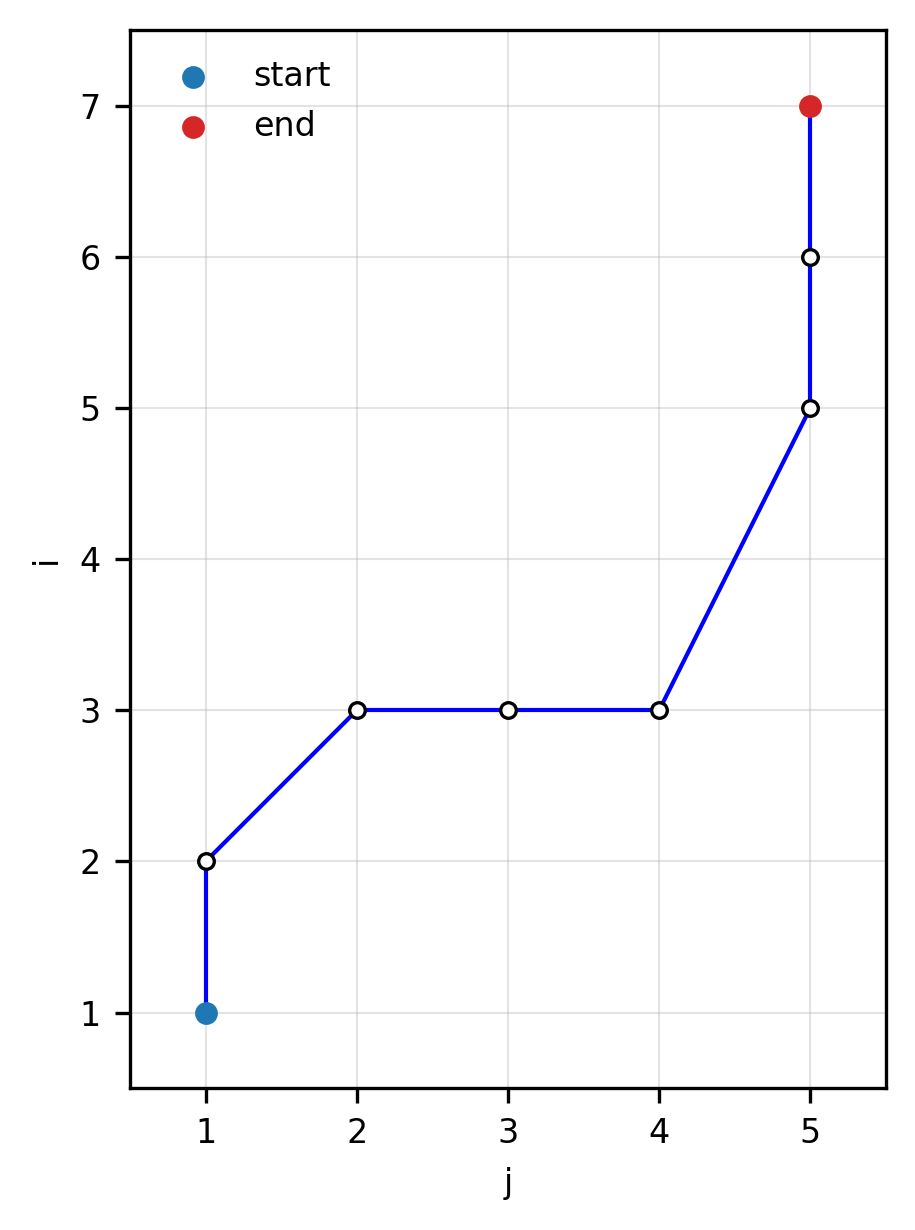

In [14]:
mypath = [[1,1],[2,1],[3,2],[3,3],[3,4],[5,5],[6,5],[7,5]]
plot_warping_path(mypath, legend_fontsize= 8, title="")
plt.show()  

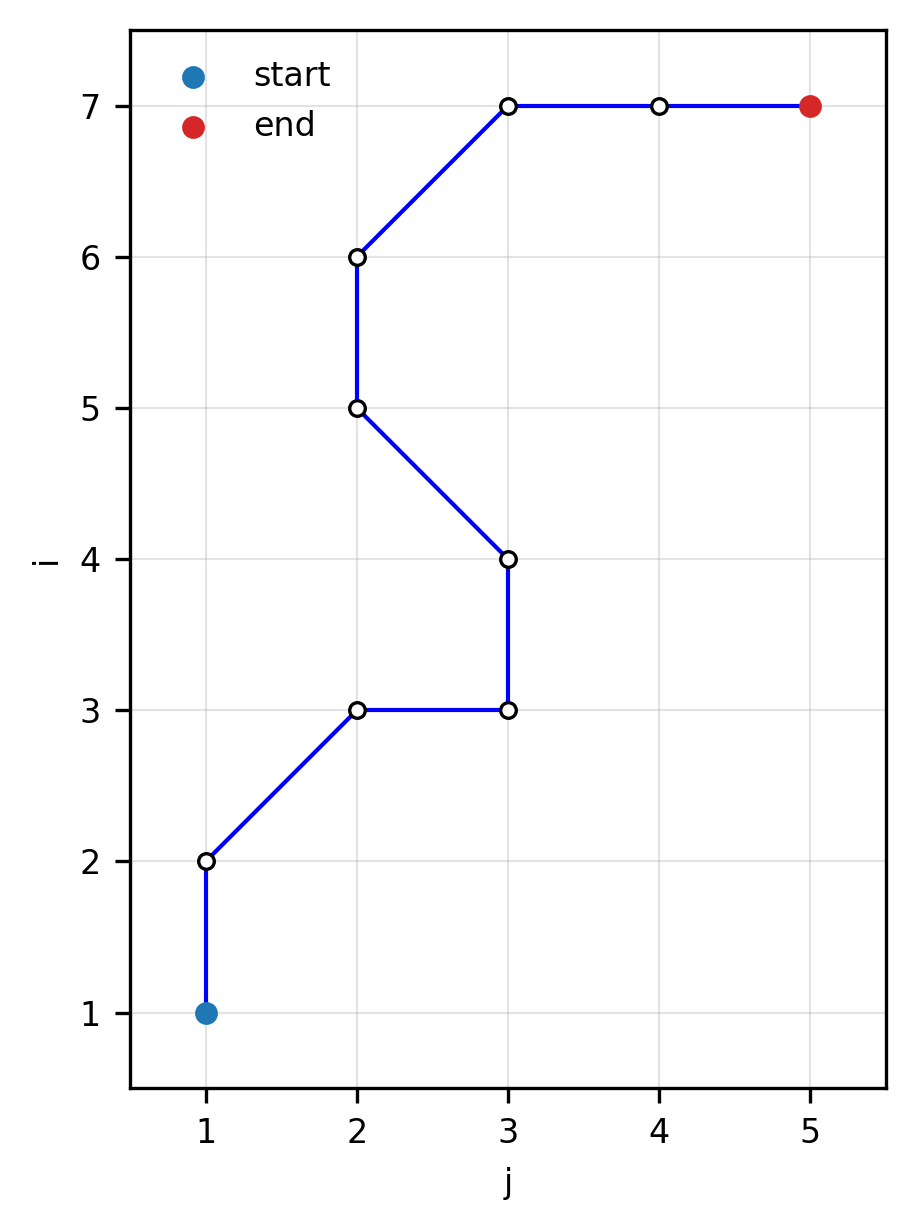

In [22]:
mypath = [[1,1],[2,1],[3,2],[3,3],[4,3],[5,2],[6,2], [7,3], [7,4], [7,5]]
plot_warping_path(mypath, legend_fontsize= 8, title="")
plt.show()  

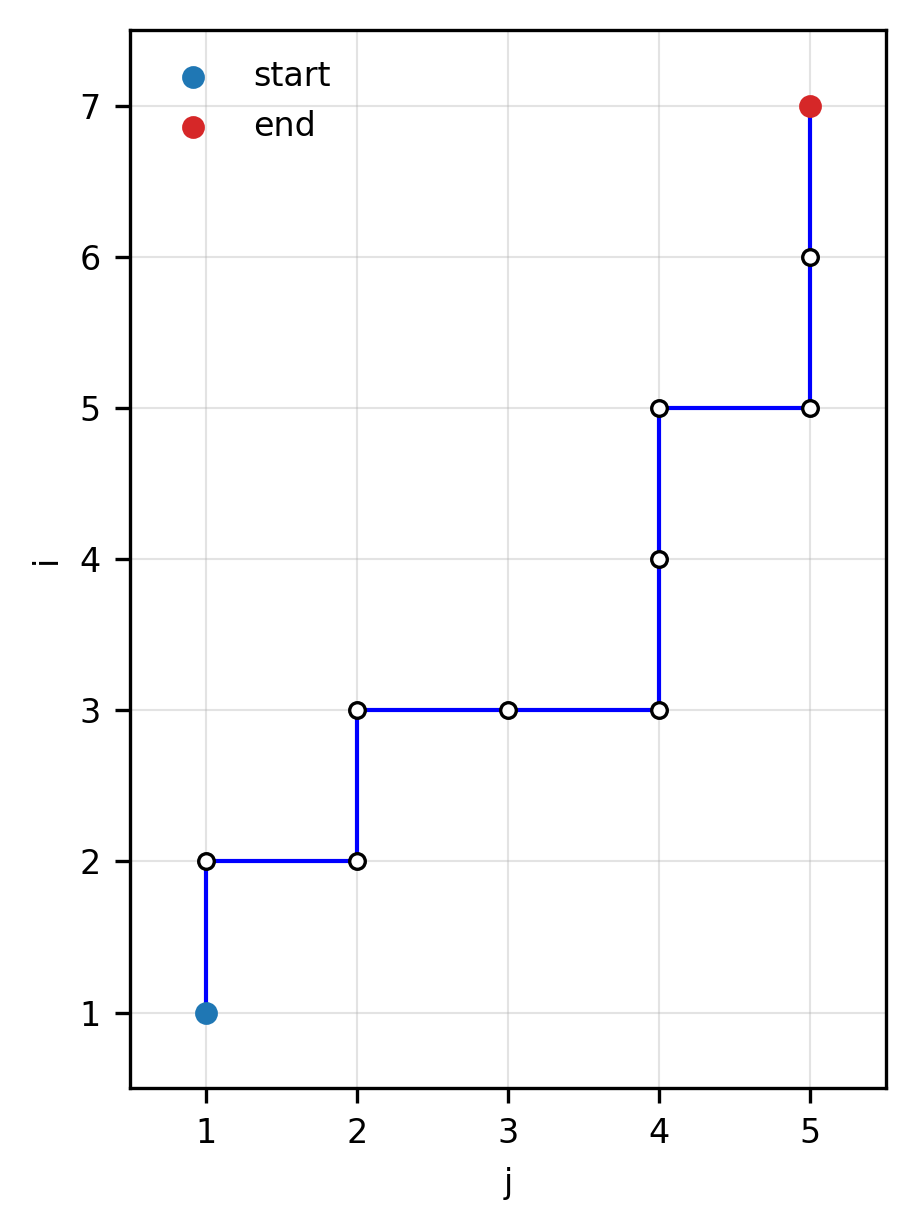

In [25]:
mypath = [[1,1],[2,1],[2,2],[3,2],[3,3],[3,4],[4,4],[5,4],[5,5],[6,5],[7,5]]
plot_warping_path(mypath, legend_fontsize= 8, title="")
plt.show()  

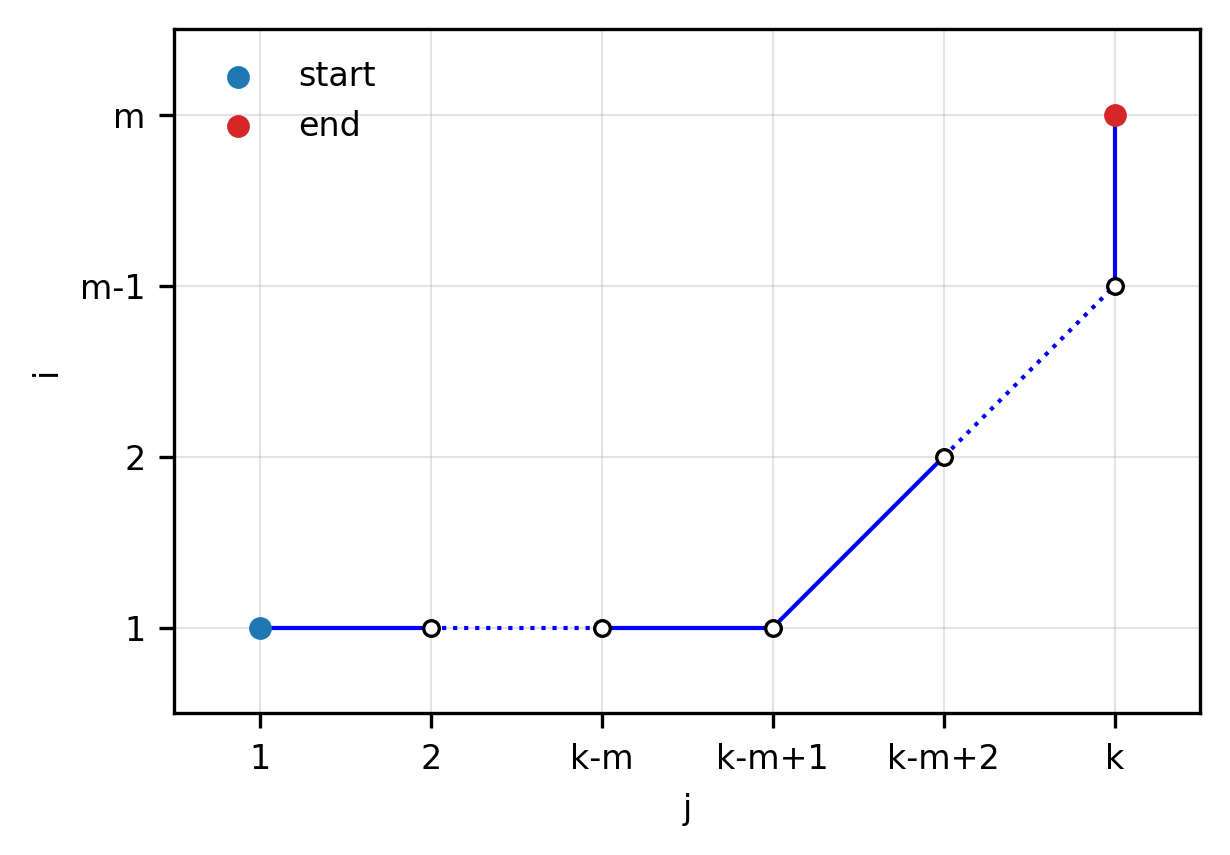

In [17]:
path = [[1, 1], [1, 2], ["right", "right"], [1, "k-m"],[1, "k-m+1"], [2, "k-m+2"], ["up", "right"], ["m-1", "k"], ["m", "k"]]
plot_warping_path(path, legend_fontsize= 8, title="", save_path="warping_path_t.pdf")
plt.show()

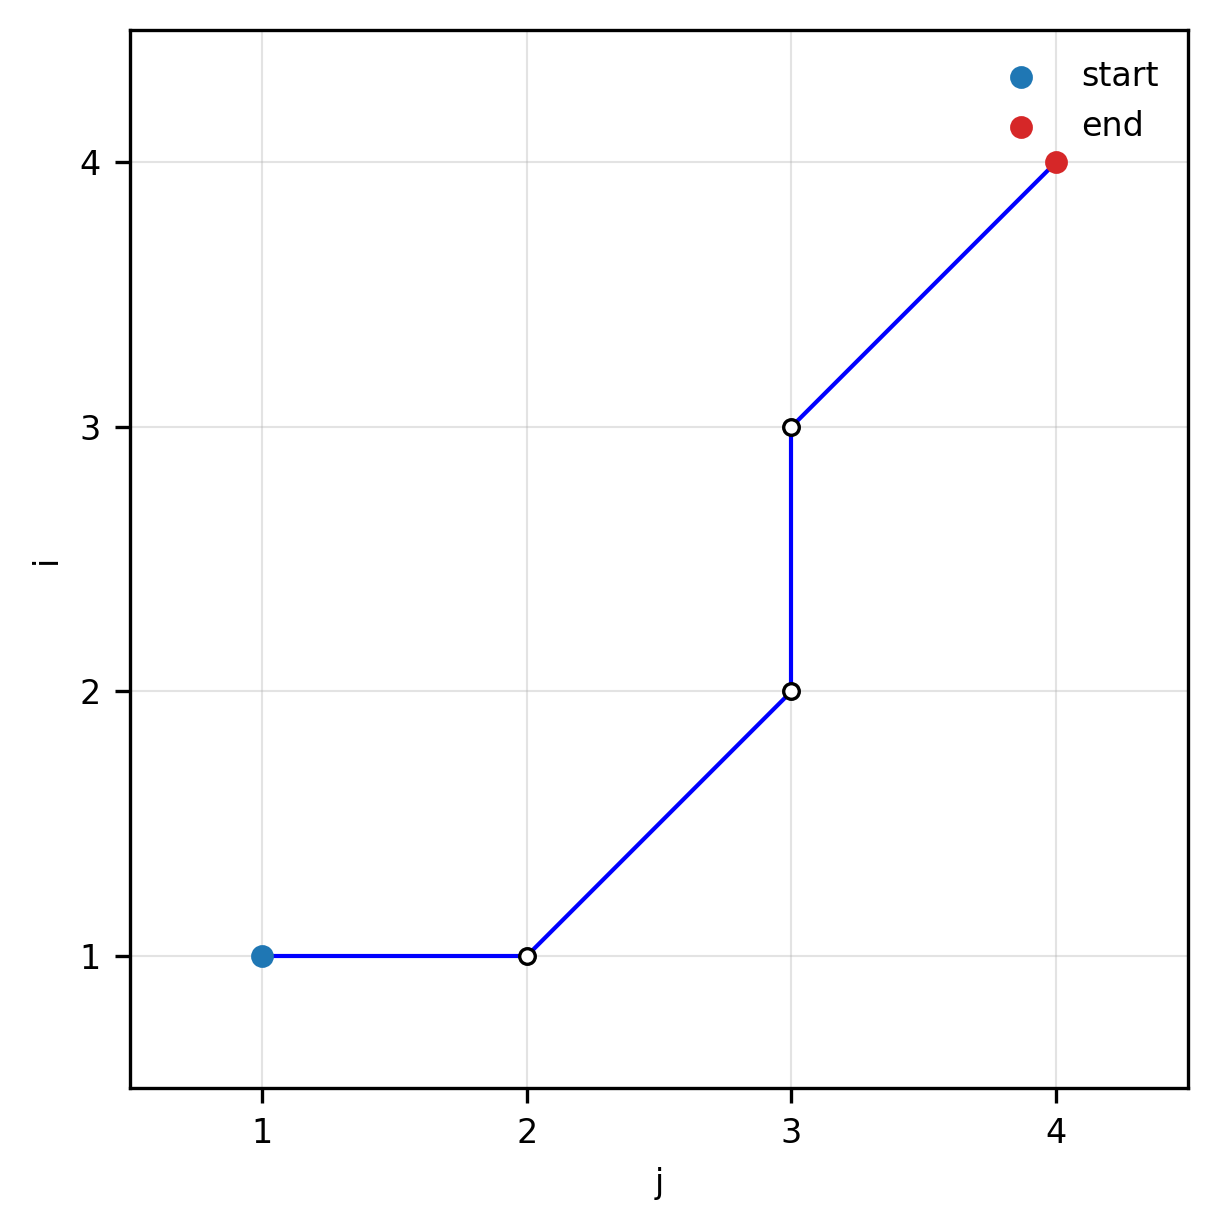

In [18]:
path2 = [[1,1],[1,2],[2,3],[3,3],[4,4]]
plot_warping_path(path2, legend_fontsize= 8, title="", save_path="warping_path_example.pdf")
plt.show()

In [27]:
def delannoy(m, n):
    D = [[0] * (n + 1) for _ in range(m + 1)]

    for i in range(m + 1):
        D[i][0] = 1
    for j in range(n + 1):
        D[0][j] = 1

    for i in range(1, m + 1):
        for j in range(1, n + 1):
            D[i][j] = D[i-1][j] + D[i][j-1] + D[i-1][j-1]

    return D[m][n]

# Example
for i in range(3,10):
    print(f"delannoy({i}, {i}) = {delannoy(i, i)}")
 # 377

delannoy(3, 3) = 63
delannoy(4, 4) = 321
delannoy(5, 5) = 1683
delannoy(6, 6) = 8989
delannoy(7, 7) = 48639
delannoy(8, 8) = 265729
delannoy(9, 9) = 1462563
